In [7]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob

In [5]:
file = glob.glob('C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi/yellow_tripdata_2009-*.parquet')
all_dfs = []
for one_filename in file:
    print(f'Loading {one_filename}')
    new_df = pl.read_parquet(one_filename, 
                                columns=['Trip_Pickup_DateTime','Trip_Dropoff_DateTime','Passenger_Count','Trip_Distance',
                                         'Payment_Type','Fare_Amt','Tip_Amt'])
    
    new_df = new_df.filter(
        (pl.col("Passenger_Count") >= 0) & 
        (pl.col("Trip_Distance") >= 0) & 
        (pl.col("Trip_Distance") <= 50) & 
        (pl.col("Fare_Amt") >= 0) & 
        (pl.col("Tip_Amt") >= 0) 
    )

    mapping = {
    "Credit": 0,
    "CREDIT": 0,
    "CASH": 1,
    "Cash": 1,
    "No Charge": 2,
    "Dispute": 3
    }

    new_df = new_df.with_columns(
        pl.col("Payment_Type").replace(mapping)
    )

    new_df = new_df.with_columns([
        pl.col("Trip_Pickup_DateTime").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S"),
        pl.col("Trip_Dropoff_DateTime").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S"),
        pl.col("Payment_Type").cast(pl.Int64)
    ])

    new_df = new_df.filter(
        (pl.col("Payment_Type") == 0)
    )

    new_df = new_df.with_columns(
        ((pl.col("Trip_Dropoff_DateTime") - pl.col("Trip_Pickup_DateTime")).dt.total_seconds() / 86400)
        .cast(pl.Int64)
        .alias("Duration_Days")
    )

    new_df = new_df.filter(
        (pl.col("Duration_Days") == 0) 
    )

    new_df = new_df.with_columns(
        ((pl.col("Trip_Dropoff_DateTime") - pl.col("Trip_Pickup_DateTime")).dt.total_seconds())
        .cast(pl.Int64)
        .alias("Duration_Seconds")
    )

    new_df = new_df.drop(["Trip_Pickup_DateTime", "Trip_Dropoff_DateTime", "Duration_Days","Payment_Type"])

    new_df = new_df.with_columns(
        pl.when(pl.col("Tip_Amt") == 0).then(0)
         .otherwise(1)
         .alias("Tip_Category")
    )

    new_df = new_df.drop(["Tip_Amt"])
    all_dfs.append(new_df)

all_data_2009 = pl.concat(all_dfs)
all_data_2009.head()

Loading C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi\yellow_tripdata_2009-01.parquet
Loading C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi\yellow_tripdata_2009-02.parquet
Loading C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi\yellow_tripdata_2009-03.parquet
Loading C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi\yellow_tripdata_2009-04.parquet
Loading C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi\yellow_tripdata_2009-05.parquet
Loading C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi\yellow_tripdata_2009-06.parquet
Loading C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi\yellow_tripdata_2009-07.parquet
Loading C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi\yellow_tripdata_2009-08.parquet
Loading C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi\yellow_tripdata_2009-09.parquet
Loading C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi\yellow_tripdata_2009-10.parquet
Loading C:/Users/ekadw/Documents/DATA/NY_Taxi/2009

Passenger_Count,Trip_Distance,Fare_Amt,Duration_Seconds,Tip_Category
i64,f64,f64,i64,i32
3,4.55,12.1,420,1
5,10.35,23.7,840,1
1,5.0,14.9,1262,1
1,0.4,5.7,585,1
1,1.6,8.7,679,1


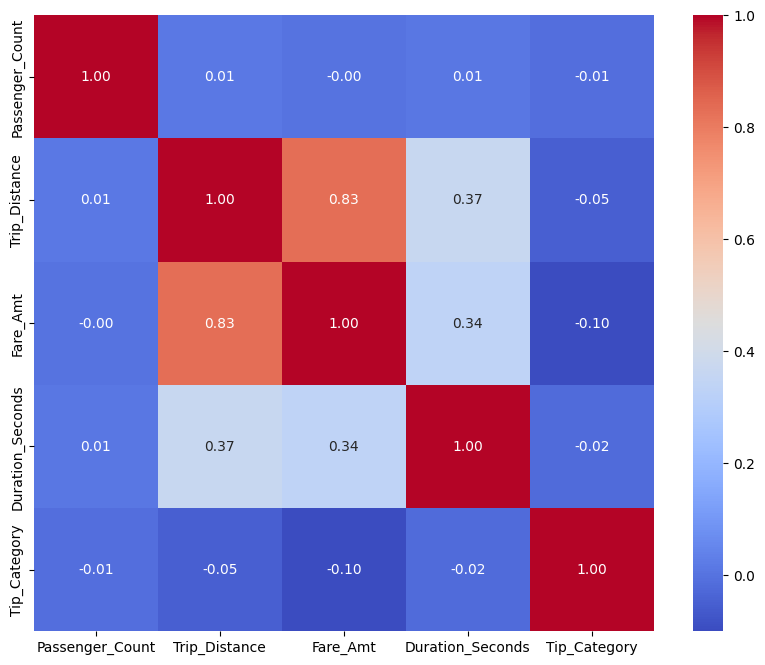

In [9]:
corr_df = all_data_2009.select(pl.all().cast(pl.Float64)).to_pandas().corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [ ]:
# There is a multicolinearity between Trip_Distance and Fare_Amt

In [10]:
y = all_data_2009.select('Tip_Category').to_numpy().ravel().astype(int)
X = all_data_2009.drop(['Tip_Category']).to_numpy()

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [12]:
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression())
])

pipeline.fit(X_train, y_train)

,steps,"[('smote', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'


In [13]:
pipeline.score(X_test,y_test)

0.7532749209453192

In [6]:
len(all_data_2009)

44891923

In [2]:
data_jan_2009 = pl.read_parquet("C:/Users/ekadw/Documents/DATA/NY_Taxi/2009/yellow_taxi/yellow_tripdata_2009-01.parquet", 
                                columns=['Trip_Pickup_DateTime','Trip_Dropoff_DateTime','Passenger_Count','Trip_Distance',
                                         'Payment_Type','Fare_Amt','Tip_Amt'])

In [3]:
len(data_jan_2009)

14092413

In [4]:
data_jan_2009.head()

Trip_Pickup_DateTime,Trip_Dropoff_DateTime,Passenger_Count,Trip_Distance,Payment_Type,Fare_Amt,Tip_Amt
str,str,i64,f64,str,f64,f64
"""2009-01-04 02:52:00""","""2009-01-04 03:02:00""",1,2.63,"""CASH""",8.9,0.0
"""2009-01-04 03:31:00""","""2009-01-04 03:38:00""",3,4.55,"""Credit""",12.1,2.0
"""2009-01-03 15:43:00""","""2009-01-03 15:57:00""",5,10.35,"""Credit""",23.7,4.74
"""2009-01-01 20:52:58""","""2009-01-01 21:14:00""",1,5.0,"""CREDIT""",14.9,3.05
"""2009-01-24 16:18:23""","""2009-01-24 16:24:56""",1,0.4,"""CASH""",3.7,0.0


In [5]:
data_jan_2009.columns

['Trip_Pickup_DateTime',
 'Trip_Dropoff_DateTime',
 'Passenger_Count',
 'Trip_Distance',
 'Payment_Type',
 'Fare_Amt',
 'Tip_Amt']

In [6]:
data_jan_2009 = data_jan_2009.rename({
    "Trip_Pickup_DateTime": "trip_pickup_dateTime",
    "Trip_Dropoff_DateTime": "trip_dropoff_dateTime",
    "Passenger_Count": "passenger_count",
    "Trip_Distance": "trip_distance",
    "Payment_Type": "payment_type",
    "Fare_Amt": "fare_amt",
    "Tip_Amt": "tip_amt"
})

In [7]:
data_jan_2009 = data_jan_2009.filter(
    (pl.col("passenger_count") >= 0) & 
    (pl.col("trip_distance") >= 0) & 
    (pl.col("trip_distance") <= 50) & 
    (pl.col("fare_amt") >= 0) & 
    (pl.col("tip_amt") >= 0) 
)
len(data_jan_2009)

14092413

In [8]:
data_jan_2009.head()

trip_pickup_dateTime,trip_dropoff_dateTime,passenger_count,trip_distance,payment_type,fare_amt,tip_amt
str,str,i64,f64,str,f64,f64
"""2009-01-04 02:52:00""","""2009-01-04 03:02:00""",1,2.63,"""CASH""",8.9,0.0
"""2009-01-04 03:31:00""","""2009-01-04 03:38:00""",3,4.55,"""Credit""",12.1,2.0
"""2009-01-03 15:43:00""","""2009-01-03 15:57:00""",5,10.35,"""Credit""",23.7,4.74
"""2009-01-01 20:52:58""","""2009-01-01 21:14:00""",1,5.0,"""CREDIT""",14.9,3.05
"""2009-01-24 16:18:23""","""2009-01-24 16:24:56""",1,0.4,"""CASH""",3.7,0.0


In [9]:
mapping = {
    "Credit": 0,
    "CREDIT": 0,
    "CASH": 1,
    "Cash": 1,
    "No Charge": 2,
    "Dispute": 3
}

data_jan_2009 = data_jan_2009.with_columns(
    pl.col("payment_type").replace(mapping)
)

In [10]:
data_jan_2009.head()

trip_pickup_dateTime,trip_dropoff_dateTime,passenger_count,trip_distance,payment_type,fare_amt,tip_amt
str,str,i64,f64,str,f64,f64
"""2009-01-04 02:52:00""","""2009-01-04 03:02:00""",1,2.63,"""1""",8.9,0.0
"""2009-01-04 03:31:00""","""2009-01-04 03:38:00""",3,4.55,"""0""",12.1,2.0
"""2009-01-03 15:43:00""","""2009-01-03 15:57:00""",5,10.35,"""0""",23.7,4.74
"""2009-01-01 20:52:58""","""2009-01-01 21:14:00""",1,5.0,"""0""",14.9,3.05
"""2009-01-24 16:18:23""","""2009-01-24 16:24:56""",1,0.4,"""1""",3.7,0.0


In [11]:
data_jan_2009 = data_jan_2009.with_columns([
    pl.col("trip_pickup_dateTime").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S"),
    pl.col("trip_dropoff_dateTime").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S"),
    pl.col("payment_type").cast(pl.Int64)
])

In [12]:
data_jan_2009 = data_jan_2009.filter(
    (pl.col("payment_type") == 0)
)
len(data_jan_2009)

3024673

In [13]:
data_jan_2009.head()

trip_pickup_dateTime,trip_dropoff_dateTime,passenger_count,trip_distance,payment_type,fare_amt,tip_amt
datetime[μs],datetime[μs],i64,f64,i64,f64,f64
2009-01-04 03:31:00,2009-01-04 03:38:00,3,4.55,0,12.1,2.0
2009-01-03 15:43:00,2009-01-03 15:57:00,5,10.35,0,23.7,4.74
2009-01-01 20:52:58,2009-01-01 21:14:00,1,5.0,0,14.9,3.05
2009-01-21 08:55:57,2009-01-21 09:05:42,1,0.4,0,5.7,1.0
2009-01-05 16:29:02,2009-01-05 16:40:21,1,1.6,0,8.7,1.3


In [14]:
data_jan_2009 = data_jan_2009.with_columns(
    ((pl.col("trip_dropoff_dateTime") - pl.col("trip_pickup_dateTime")).dt.total_seconds() / 86400)
    .cast(pl.Int64)
    .alias("duration_days")
)

In [15]:
data_jan_2009.head()

trip_pickup_dateTime,trip_dropoff_dateTime,passenger_count,trip_distance,payment_type,fare_amt,tip_amt,duration_days
datetime[μs],datetime[μs],i64,f64,i64,f64,f64,i64
2009-01-04 03:31:00,2009-01-04 03:38:00,3,4.55,0,12.1,2.0,0
2009-01-03 15:43:00,2009-01-03 15:57:00,5,10.35,0,23.7,4.74,0
2009-01-01 20:52:58,2009-01-01 21:14:00,1,5.0,0,14.9,3.05,0
2009-01-21 08:55:57,2009-01-21 09:05:42,1,0.4,0,5.7,1.0,0
2009-01-05 16:29:02,2009-01-05 16:40:21,1,1.6,0,8.7,1.3,0


In [16]:
data_jan_2009 = data_jan_2009.filter(
    (pl.col("duration_days") == 0) 
)
len(data_jan_2009)

3024652

In [17]:
data_jan_2009 = data_jan_2009.with_columns(
    ((pl.col("trip_dropoff_dateTime") - pl.col("trip_pickup_dateTime")).dt.total_seconds())
    .cast(pl.Int64)
    .alias("duration_seconds")
)

In [18]:
data_jan_2009.head()

trip_pickup_dateTime,trip_dropoff_dateTime,passenger_count,trip_distance,payment_type,fare_amt,tip_amt,duration_days,duration_seconds
datetime[μs],datetime[μs],i64,f64,i64,f64,f64,i64,i64
2009-01-04 03:31:00,2009-01-04 03:38:00,3,4.55,0,12.1,2.0,0,420
2009-01-03 15:43:00,2009-01-03 15:57:00,5,10.35,0,23.7,4.74,0,840
2009-01-01 20:52:58,2009-01-01 21:14:00,1,5.0,0,14.9,3.05,0,1262
2009-01-21 08:55:57,2009-01-21 09:05:42,1,0.4,0,5.7,1.0,0,585
2009-01-05 16:29:02,2009-01-05 16:40:21,1,1.6,0,8.7,1.3,0,679


In [19]:
data_jan_2009 = data_jan_2009.drop(["trip_pickup_dateTime", "trip_dropoff_dateTime", "duration_days","payment_type"])

In [20]:
data_jan_2009.head()

passenger_count,trip_distance,fare_amt,tip_amt,duration_seconds
i64,f64,f64,f64,i64
3,4.55,12.1,2.0,420
5,10.35,23.7,4.74,840
1,5.0,14.9,3.05,1262
1,0.4,5.7,1.0,585
1,1.6,8.7,1.3,679


In [21]:
data_jan_2009 = data_jan_2009.with_columns(
    ((pl.col("tip_amt") / pl.col("fare_amt")) * 100).alias("tip_percentage")
)

In [22]:
data_jan_2009["tip_percentage"].mean()

20.788678406124838

In [23]:
data_jan_2009.head()

passenger_count,trip_distance,fare_amt,tip_amt,duration_seconds,tip_percentage
i64,f64,f64,f64,i64,f64
3,4.55,12.1,2.0,420,16.528926
5,10.35,23.7,4.74,840,20.0
1,5.0,14.9,3.05,1262,20.469799
1,0.4,5.7,1.0,585,17.54386
1,1.6,8.7,1.3,679,14.942529


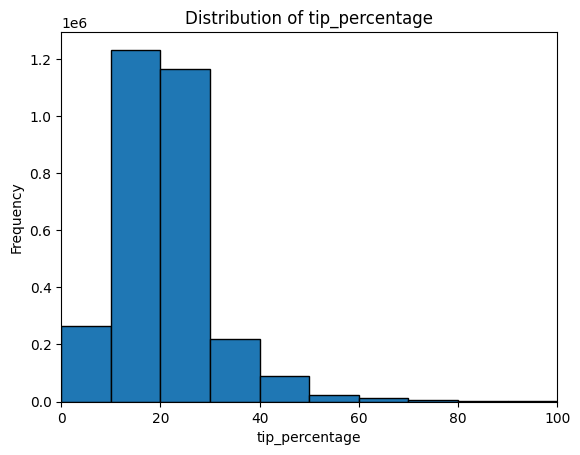

In [24]:
values = data_jan_2009["tip_percentage"].to_numpy()

plt.hist(values, bins=400, edgecolor='black')
plt.xlabel("tip_percentage")
plt.xlim(0, 100)
plt.ylabel("Frequency")
plt.title("Distribution of tip_percentage")
plt.show()

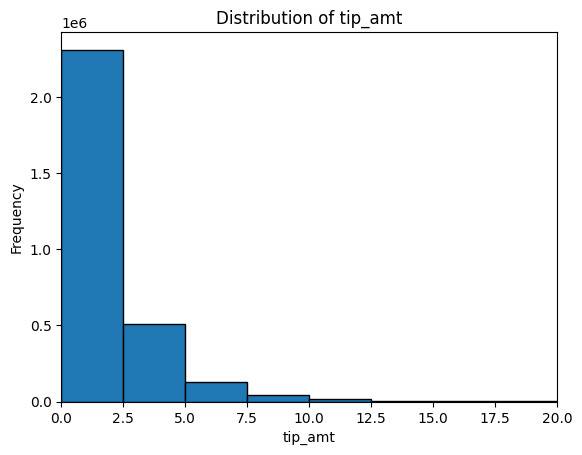

In [25]:
values = data_jan_2009["tip_amt"].to_numpy()

plt.hist(values, bins=40, edgecolor='black')
plt.xlabel("tip_amt")
plt.xlim(0, 20)
plt.ylabel("Frequency")
plt.title("Distribution of tip_amt")
plt.show()

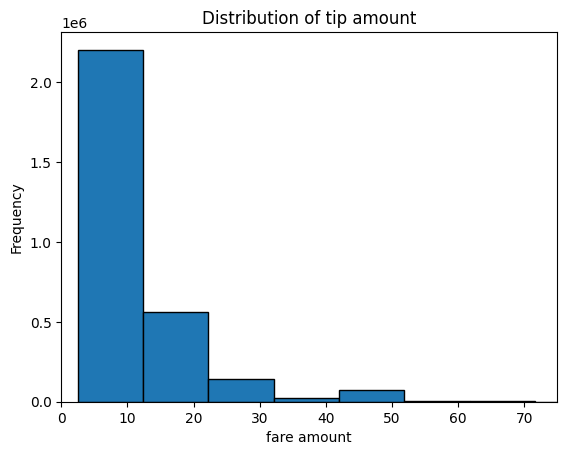

In [26]:
values = data_jan_2009["fare_amt"].to_numpy()

plt.hist(values, bins=20, edgecolor='black')
plt.xlim(0, 75)
plt.xlabel("fare amount")
plt.ylabel("Frequency")
plt.title("Distribution of tip amount")
plt.show()

In [27]:
data_jan_2009 = data_jan_2009.with_columns(
    pl.when(pl.col("tip_percentage") == 0).then(1)
     .otherwise(0)
     .alias("tip_category")
)


In [28]:
data_jan_2009.head()

passenger_count,trip_distance,fare_amt,tip_amt,duration_seconds,tip_percentage,tip_category
i64,f64,f64,f64,i64,f64,i32
3,4.55,12.1,2.0,420,16.528926,0
5,10.35,23.7,4.74,840,20.0,0
1,5.0,14.9,3.05,1262,20.469799,0
1,0.4,5.7,1.0,585,17.54386,0
1,1.6,8.7,1.3,679,14.942529,0


In [29]:
data_jan_2009["tip_category"].value_counts()

tip_category,count
i32,u32
0,2932436
1,92216


In [30]:
data_jan_2009 = data_jan_2009.drop(["tip_amt"])

In [31]:
data_jan_2009 = data_jan_2009.drop(["tip_percentage"])

# print(mean_tips)

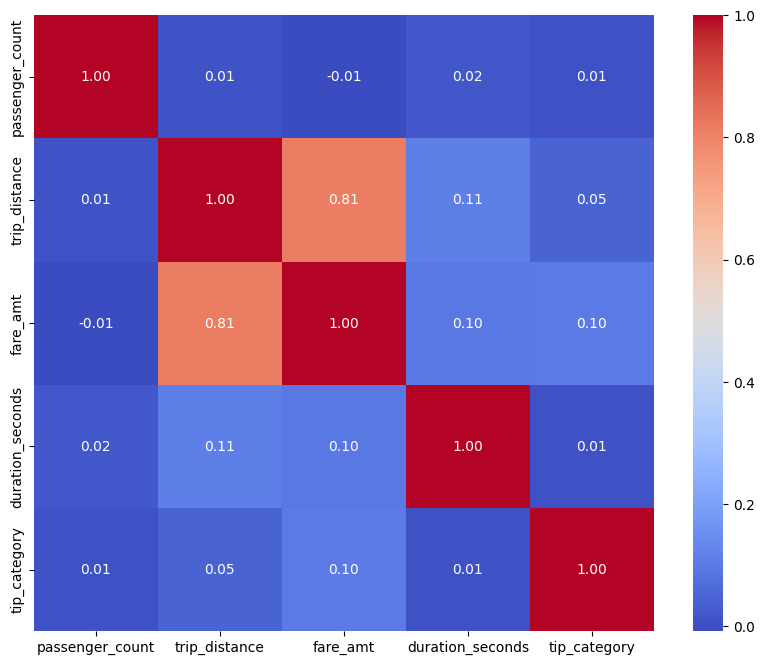

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_df = data_jan_2009.select(pl.all().cast(pl.Float64)).to_pandas().corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [33]:
#y = data_jan_2009['tip_or_no']
#X = data_jan_2009.drop(['tip_or_no'])

y = data_jan_2009.select('tip_category').to_numpy().ravel().astype(int)
X = data_jan_2009.drop(['tip_category']).to_numpy()


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [35]:
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression())
])

pipeline.fit(X_train, y_train)

,steps,"[('smote', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'


In [36]:
pipeline.score(X_test,y_test)

0.7650661894035239

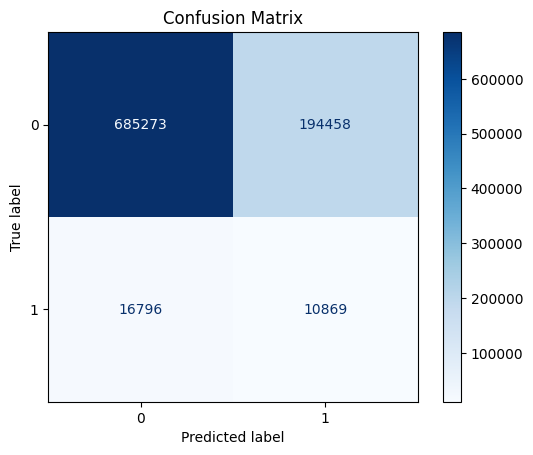

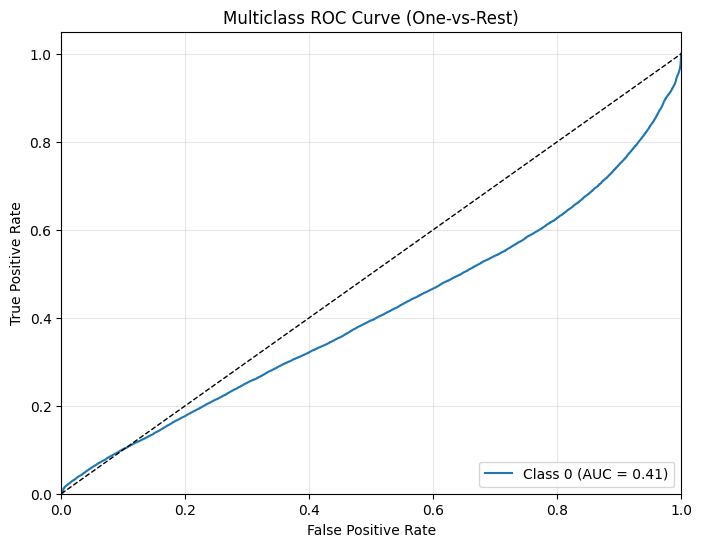

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# --- Assume you already have X (features) and y (target with 4 categories) ---
# X: shape (n_samples, n_features)
# y: shape (n_samples, )

# 1. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Build pipeline with SMOTE + Scaling + SGDClassifier
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', SGDClassifier(loss='log_loss', random_state=42, max_iter=1000, tol=1e-3))
])

# 3. Train the model
pipeline.fit(X_train, y_train)

# 4. Predictions
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)  # Needed for ROC

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# --- ROC Curve for Multiclass ---
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(8,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


In [38]:
pipeline.score(X_test,y_test)

0.7671865425900048

In [39]:
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt

# y_true: actual labels (0/1)
# y_score: predicted probabilities or decision scores for class 1
# y_pred: predicted class labels (0/1)

y_true = y
y_score =

def fix_label_flipping(y_true, y_score):
    """Detect if ROC AUC < 0.5 and flip scores if necessary."""
    auc = roc_auc_score(y_true, y_score)
    if auc < 0.5:
        # Flip the scores
        y_score = 1 - y_score
        auc = roc_auc_score(y_true, y_score)
        flipped = True
    else:
        flipped = False
    return y_score, auc, flipped

# Example usage:
# Suppose you already have predictions:
# y_true = ...
# y_score = model.predict_proba(X)[:,1]  # probabilities for class 1
# y_pred  = (y_score > 0.5).astype(int)

y_score_fixed, auc_fixed, flipped = fix_label_flipping(y_true, y_score)
print(f"AUC after fixing: {auc_fixed:.3f} (Flipped: {flipped})")

# Plot the corrected ROC curve
fpr, tpr, _ = roc_curve(y_true, y_score_fixed)
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_fixed:.2f})")
plt.plot([0,1], [0,1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Corrected ROC Curve")
plt.legend()
plt.show()


NameError: name 'y_true' is not defined